In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [2]:
data=pd.read_csv("/content/Mall_Customers.csv")

In [3]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.drop('CustomerID',axis=1)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [6]:
le=LabelEncoder()
data['Genre']=le.fit_transform(data['Genre'])

In [8]:
def spending_score(score):
  if score < 40:
    return 0
  elif score<70:
    return 1
  else:
    return 2

In [9]:
data['Spending Category']=data['Spending Score (1-100)'].apply(spending_score)

In [11]:
x=data[['Genre','Age','Annual Income (k$)']]
y=data['Spending Category']

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
model=DecisionTreeClassifier(criterion='gini',max_depth=4,random_state=42)

In [17]:
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [18]:
pred=model.predict(x_test)

In [19]:
acc=accuracy_score(y_test,pred)
print(acc)

0.825


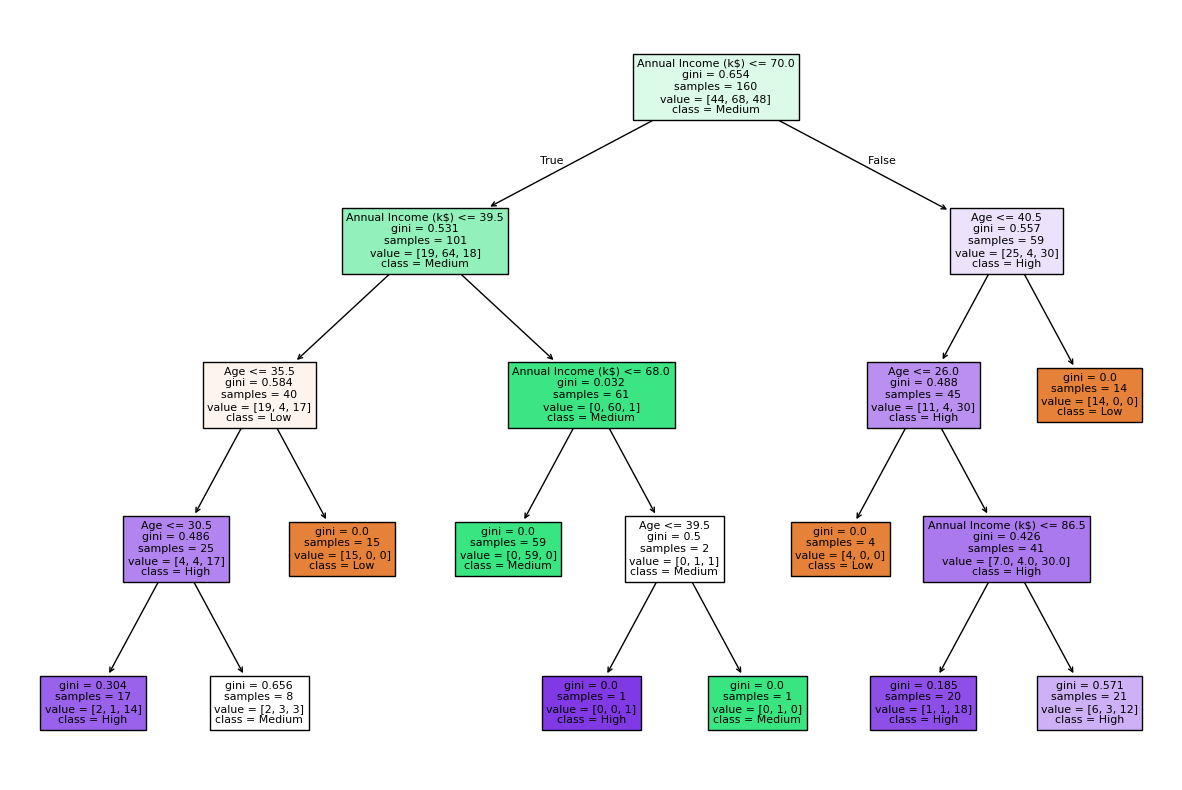

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
plot_tree(model,feature_names=['Genre', 'Age', 'Annual Income (k$)'],
    class_names=['Low', 'Medium', 'High'],
    filled=True)
plt.show()

In [25]:
import seaborn as sns

In [30]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred)
print(cm)

[[10  1  4]
 [ 0 17  2]
 [ 0  0  6]]


<Axes: >

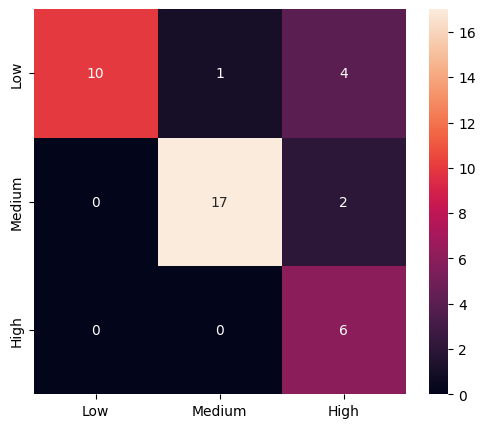

In [31]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['Low','Medium','High'],yticklabels=['Low','Medium','High'])